# Z-Prefix VSD Knee Cropping Pipeline

Crop bilateral knee volumes from full-body (no head) z-prefix CT scans.

**Problem**: Direct peak detection on the full-body bone profile is unreliable —
the pelvis/shoulder peaks dominate and the knee peak may not be detected at all.

**Approach — two-stage crop**:
1. **Fixed z-crop**: Discard the top 45% of slices (shoulders, chest, upper abdomen)
2. **Knee identification**: On the cropped lower-body sub-volume, find the knee peak
   in the **15–35% z-range** using the same `find_peaks` approach proven on regular VSD

**Input**: NIfTI files from `data/raw/VSD_Dataset/z*/`
**Output**: Cropped knee volumes to `data/raw/healthy/{Left|Right}/VSD_z{id}_{side}.nii.gz`

## 1 — Imports & Configuration

In [1]:
import os
import gc
import json
import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.ndimage import gaussian_filter1d, binary_closing, binary_dilation
from scipy.ndimage import label as ndimage_label
from scipy.signal import find_peaks

# ============================================================
# Configuration
# ============================================================
PROJECT_ROOT = Path(r"c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject")
VSD_ROOT = PROJECT_ROOT / "data" / "raw" / "VSD_Dataset"

# Output (same directory structure as regular VSD knee cropping)
OUTPUT_DIR = PROJECT_ROOT / "data" / "raw" / "healthy"
OUTPUT_DIR_LEFT = OUTPUT_DIR / "Left"
OUTPUT_DIR_RIGHT = OUTPUT_DIR / "Right"
FIG_DIR = PROJECT_ROOT / "reports" / "figures" / "z_vsd_crop"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Stage 1: Fixed z-crop — discard upper body
Z_CROP_TOP_PCT = 0.45  # fraction of total z to discard from the top (superior end)

# Stage 2: Knee identification on cropped sub-volume
BONE_HU_THRESHOLD = 200       # HU threshold for bone detection
KNEE_Z_RANGE = (0.15, 0.35)   # knee position in cropped sub-volume
KNEE_FALLBACK_PCT = 0.25      # fallback target if no candidate in range
KNEE_CROP_MARGIN_MM = 100.0   # +/-100mm around knee center

# Bone profile peak detection
PROFILE_SMOOTH_SIGMA = 20
PEAK_MIN_HEIGHT_FRAC = 0.2
PEAK_MIN_DISTANCE = 80

# Bilateral leg separation
CC_BONE_HU = 300  # higher threshold excludes CT scanner table (~40-120 HU)

# Knee volume cropping
XY_PAD_PIXELS = 15  # padding around leg bounding box in x/y

print("Configuration loaded.")
print(f"  VSD root     : {VSD_ROOT}")
print(f"  Output dir   : {OUTPUT_DIR}")
print(f"  Figures dir  : {FIG_DIR}")
print(f"  Z-crop top   : {Z_CROP_TOP_PCT*100:.0f}% discarded")
print(f"  Knee z-range : {KNEE_Z_RANGE[0]*100:.0f}-{KNEE_Z_RANGE[1]*100:.0f}% of cropped volume")
print(f"  Crop margin  : +/-{KNEE_CROP_MARGIN_MM}mm")

Configuration loaded.
  VSD root     : c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\raw\VSD_Dataset
  Output dir   : c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\raw\healthy
  Figures dir  : c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\reports\figures\z_vsd_crop
  Z-crop top   : 45% discarded
  Knee z-range : 15-35% of cropped volume
  Crop margin  : +/-100.0mm


## 2 — Data Discovery

In [2]:
def discover_z_cases(vsd_root):
    """Discover z-prefix subjects and extract NIfTI header metadata."""
    cases = []
    for subject_name in sorted(os.listdir(vsd_root)):
        if not subject_name.startswith("z"):
            continue
        subject_dir = vsd_root / subject_name
        if not subject_dir.is_dir():
            continue

        subdirs = [d for d in subject_dir.iterdir() if d.is_dir()]
        if not subdirs:
            continue
        smir_dir = subdirs[0]
        smir_name = smir_dir.name

        nii_path = smir_dir / f"{smir_name}.nii"
        if not nii_path.exists():
            print(f"  WARNING: NIfTI not found for {subject_name}")
            continue

        # Read header only (no full array load)
        reader = sitk.ImageFileReader()
        reader.SetFileName(str(nii_path))
        reader.ReadImageInformation()

        size = reader.GetSize()        # (x, y, z)
        spacing = reader.GetSpacing()  # (x, y, z)

        cases.append({
            "subject_id": subject_name,
            "nii_path": str(nii_path),
            "size_xyz": size,
            "spacing_x": round(spacing[0], 6),
            "spacing_y": round(spacing[1], 6),
            "spacing_z": round(spacing[2], 6),
            "n_slices": size[2],
            "phys_z_mm": round(size[2] * spacing[2], 1),
        })
        print(f"  {subject_name}: {size}, spacing_z={spacing[2]:.4f}mm, "
              f"z-extent={size[2]*spacing[2]:.0f}mm")

    return cases


print("Discovering z-prefix VSD subjects...\n")
z_cases = discover_z_cases(VSD_ROOT)
print(f"\nTotal: {len(z_cases)} z-prefix subjects found")

df_cases = pd.DataFrame([{k: v for k, v in c.items() if k != "nii_path"}
                          for c in z_cases])
display(df_cases)

Discovering z-prefix VSD subjects...

  z001: (512, 512, 3223), spacing_z=0.5000mm, z-extent=1612mm
  z004: (512, 512, 3235), spacing_z=0.5000mm, z-extent=1618mm
  z009: (512, 512, 3228), spacing_z=0.5000mm, z-extent=1614mm
  z013: (512, 512, 3113), spacing_z=0.5000mm, z-extent=1556mm
  z023: (512, 512, 3122), spacing_z=0.5000mm, z-extent=1561mm
  z027: (512, 512, 3208), spacing_z=0.5000mm, z-extent=1604mm
  z035: (512, 512, 3083), spacing_z=0.5000mm, z-extent=1542mm
  z036: (512, 512, 3383), spacing_z=0.5000mm, z-extent=1692mm
  z042: (512, 512, 3054), spacing_z=0.5000mm, z-extent=1527mm
  z046: (512, 512, 6564), spacing_z=0.2500mm, z-extent=1641mm
  z049: (512, 512, 3299), spacing_z=0.5000mm, z-extent=1650mm
  z050: (512, 512, 6005), spacing_z=0.2500mm, z-extent=1501mm
  z055: (512, 512, 3183), spacing_z=0.5000mm, z-extent=1592mm
  z056: (512, 512, 3467), spacing_z=0.5000mm, z-extent=1734mm
  z057: (512, 512, 3218), spacing_z=0.5000mm, z-extent=1609mm
  z061: (512, 512, 3273), spacin

,subject_id,size_xyz,spacing_x,spacing_y,spacing_z,n_slices,phys_z_mm
0,z001,"(512, 512, 3223)",0.990234,0.990234,0.500000,3223,1611.5
1,z004,"(512, 512, 3235)",1.035156,1.035156,0.500000,3235,1617.5
2,z009,"(512, 512, 3228)",1.115234,1.115234,0.500000,3228,1614.0
3,z013,"(512, 512, 3113)",1.269531,1.269531,0.500000,3113,1556.5
4,z023,"(512, 512, 3122)",1.035156,1.035156,0.500000,3122,1561.0
5,z027,"(512, 512, 3208)",1.269531,1.269531,0.500000,3208,1604.0
6,z035,"(512, 512, 3083)",1.269531,1.269531,0.500000,3083,1541.5
7,z036,"(512, 512, 3383)",1.269531,1.269531,0.500000,3383,1691.5
8,z042,"(512, 512, 3054)",1.009766,1.009766,0.500000,3054,1527.0
9,z046,"(512, 512, 6564)",1.269531,1.269531,0.249967,6564,1640.8


## 3 — Helper Functions

All pipeline functions in one cell for easy reference:

1. `crop_upper_body()` — fixed z-crop to discard upper body
2. `find_knee_in_cropped()` — knee identification on cropped sub-volume (15-35% range)
3. `_is_table_component()` + `separate_legs_cc()` — bilateral leg separation (from `vsd_knee_cropping.ipynb`)
4. `crop_knee_volume()` — crop single knee with spatial metadata (from `vsd_knee_cropping.ipynb`)

In [3]:
# ── Stage 1: Fixed percentage z-crop ─────────────────────────────────────────

def crop_upper_body(arr, top_fraction=Z_CROP_TOP_PCT):
    """Discard the top `top_fraction` of slices (upper body: shoulders, chest).

    In these scans, slice 0 = superior (neck) and slice max = inferior (feet).
    We discard the first `top_fraction` of slices to remove everything above
    the pelvis region.

    Returns: (cropped_array, cut_slice_index)
    """
    cut_slice = int(arr.shape[0] * top_fraction)
    return arr[cut_slice:], cut_slice


# ── Stage 2: Knee identification on cropped sub-volume ───────────────────────

def find_knee_in_cropped(arr_cropped, spacing_z):
    """Find knee center in a lower-body sub-volume using 15-35% z-range.

    After discarding the upper body, the cropped volume runs from approximately
    pelvis -> knees -> ankles -> feet.  The knee joint produces a distinctive
    bone-area peak in the 15-35% range of this cropped z-extent.

    Returns: (knee_slice, z_mm, smoothed, peaks, used_fallback)
    """
    bone_area = (arr_cropped > BONE_HU_THRESHOLD).sum(axis=(1, 2)).astype(float)
    smoothed = gaussian_filter1d(bone_area, sigma=PROFILE_SMOOTH_SIGMA)

    peaks, _ = find_peaks(
        smoothed,
        height=np.max(smoothed) * PEAK_MIN_HEIGHT_FRAC,
        distance=PEAK_MIN_DISTANCE,
        prominence=np.max(smoothed) * 0.05,
    )

    z_mm = np.arange(len(bone_area)) * spacing_z
    total_z = float(z_mm[-1])

    lo = total_z * KNEE_Z_RANGE[0]
    hi = total_z * KNEE_Z_RANGE[1]
    candidates = [p for p in peaks if lo <= z_mm[p] <= hi]

    if candidates:
        knee_slice = max(candidates, key=lambda p: smoothed[p])
        used_fallback = False
    else:
        # Fallback: peak closest to 25% of cropped z-extent
        target = total_z * KNEE_FALLBACK_PCT
        knee_slice = min(peaks, key=lambda p: abs(z_mm[p] - target))
        used_fallback = True

    return int(knee_slice), z_mm, smoothed, peaks, used_fallback


# ── Stage 3: Bilateral leg separation (from vsd_knee_cropping.ipynb) ─────────

def _is_table_component(mask, img_width, img_height):
    """Return True if a CC component looks like the CT scanner table."""
    x_coords = np.where(mask.any(axis=0))[0]
    y_coords = np.where(mask.any(axis=1))[0]
    x_span = x_coords.max() - x_coords.min() + 1
    y_span = y_coords.max() - y_coords.min() + 1
    y_center = y_coords.mean()
    wide = x_span > 0.6 * img_width
    flat = y_span / max(x_span, 1) < 0.3
    at_bottom = y_center > 0.7 * img_height
    return wide and flat and at_bottom


def separate_legs_cc(arr, knee_slice, spacing_xy):
    """Separate bilateral legs using connected-component analysis.

    Ported verbatim from vsd_knee_cropping.ipynb.
    Uses HU>300 to exclude CT table, gentle morphology to avoid bridging
    the inter-knee gap, and shape heuristics to filter table components.
    """
    slab_half = 10
    z_lo = max(0, knee_slice - slab_half)
    z_hi = min(arr.shape[0], knee_slice + slab_half)
    slab = arr[z_lo:z_hi]

    bone_slab = (slab > CC_BONE_HU).any(axis=0).astype(np.uint8)
    struct = np.ones((5, 5), dtype=np.uint8)
    bone_closed = binary_closing(bone_slab, structure=struct, iterations=1).astype(np.uint8)
    bone_closed = binary_dilation(bone_closed, iterations=2).astype(np.uint8)

    labeled, n_components = ndimage_label(bone_closed)
    img_h, img_w = labeled.shape

    leg_candidates = []
    table_filtered = 0
    for i in range(1, n_components + 1):
        mask = labeled == i
        if _is_table_component(mask, img_w, img_h):
            table_filtered += 1
            continue
        leg_candidates.append((i, int(mask.sum())))

    leg_candidates.sort(key=lambda x: x[1], reverse=True)

    if len(leg_candidates) < 2:
        raise ValueError(
            f"Expected 2 legs but found {len(leg_candidates)} candidate(s) "
            f"({n_components} raw, {table_filtered} table-filtered)."
        )

    leg_labels = [leg_candidates[0][0], leg_candidates[1][0]]
    legs = []
    for lab in leg_labels:
        mask = labeled == lab
        x_coords = np.where(mask.any(axis=0))[0]
        y_coords = np.where(mask.any(axis=1))[0]
        legs.append({
            "label": lab,
            "x_min": int(x_coords.min()),
            "x_max": int(x_coords.max()) + 1,
            "y_min": int(y_coords.min()),
            "y_max": int(y_coords.max()) + 1,
            "x_center": float(x_coords.mean()),
        })

    legs.sort(key=lambda l: l["x_center"])
    legs[0]["side"] = "Left"
    legs[1]["side"] = "Right"

    return legs, labeled, bone_closed


# ── Stage 4: Crop individual knee volumes (from vsd_knee_cropping.ipynb) ─────

def crop_knee_volume(img, arr, knee_slice, leg, crop_margin_mm=KNEE_CROP_MARGIN_MM,
                     xy_pad=XY_PAD_PIXELS):
    """Crop a single knee volume with correct spatial metadata.

    Ported from vsd_knee_cropping.ipynb.
    """
    spacing = img.GetSpacing()

    margin_slices = int(crop_margin_mm / spacing[2])
    z_min = max(0, knee_slice - margin_slices)
    z_max = min(arr.shape[0], knee_slice + margin_slices)

    x_min = max(0, leg["x_min"] - xy_pad)
    x_max = min(arr.shape[2], leg["x_max"] + xy_pad)
    y_min = max(0, leg["y_min"] - xy_pad)
    y_max = min(arr.shape[1], leg["y_max"] + xy_pad)

    cropped_arr = arr[z_min:z_max, y_min:y_max, x_min:x_max].copy()

    cropped_img = sitk.GetImageFromArray(cropped_arr)
    cropped_img.SetSpacing(spacing)

    origin = img.GetOrigin()
    direction = img.GetDirection()
    new_origin = (
        origin[0] + x_min * spacing[0] * direction[0] + y_min * spacing[1] * direction[1],
        origin[1] + x_min * spacing[0] * direction[3] + y_min * spacing[1] * direction[4],
        origin[2] + z_min * spacing[2] * direction[8],
    )
    cropped_img.SetOrigin(new_origin)
    cropped_img.SetDirection(direction)

    crop_info = {
        "z_min": z_min, "z_max": z_max,
        "y_min": y_min, "y_max": y_max,
        "x_min": x_min, "x_max": x_max,
        "cropped_shape": cropped_arr.shape,
        "phys_z_mm": round((z_max - z_min) * spacing[2], 1),
    }
    return cropped_img, crop_info


print("All helper functions defined.")

All helper functions defined.


## 4 — Test on 3 Representative Subjects

Run the full pipeline on first, middle, and last subjects with detailed
4-panel diagnostic figures:
1. Coronal view of cropped volume with knee line and search window
2. Bone profile with peaks and 15-35% window highlighted
3. Axial slice at knee with CC leg bounding boxes
4. Summary info panel

Testing on 3 representative subjects:
  ['z001', 'z049', 'z066']

Subject: z001
  Full volume: (3223, 512, 512), z-extent=1612mm
  Cropped: removed top 1450 slices (725mm)
  Cropped volume: (1773, 512, 512), z-extent=886mm
  Knee: slice 630 in cropped (315mm, 35.5%) [FALLBACK]
  Knee (full vol): slice 2080
  Legs: 2 found
    Left: x=[145,238] y=[230,332]
    Right: x=[331,417] y=[235,313]
  Inter-leg gap: 93px
  Status: [FAIL]


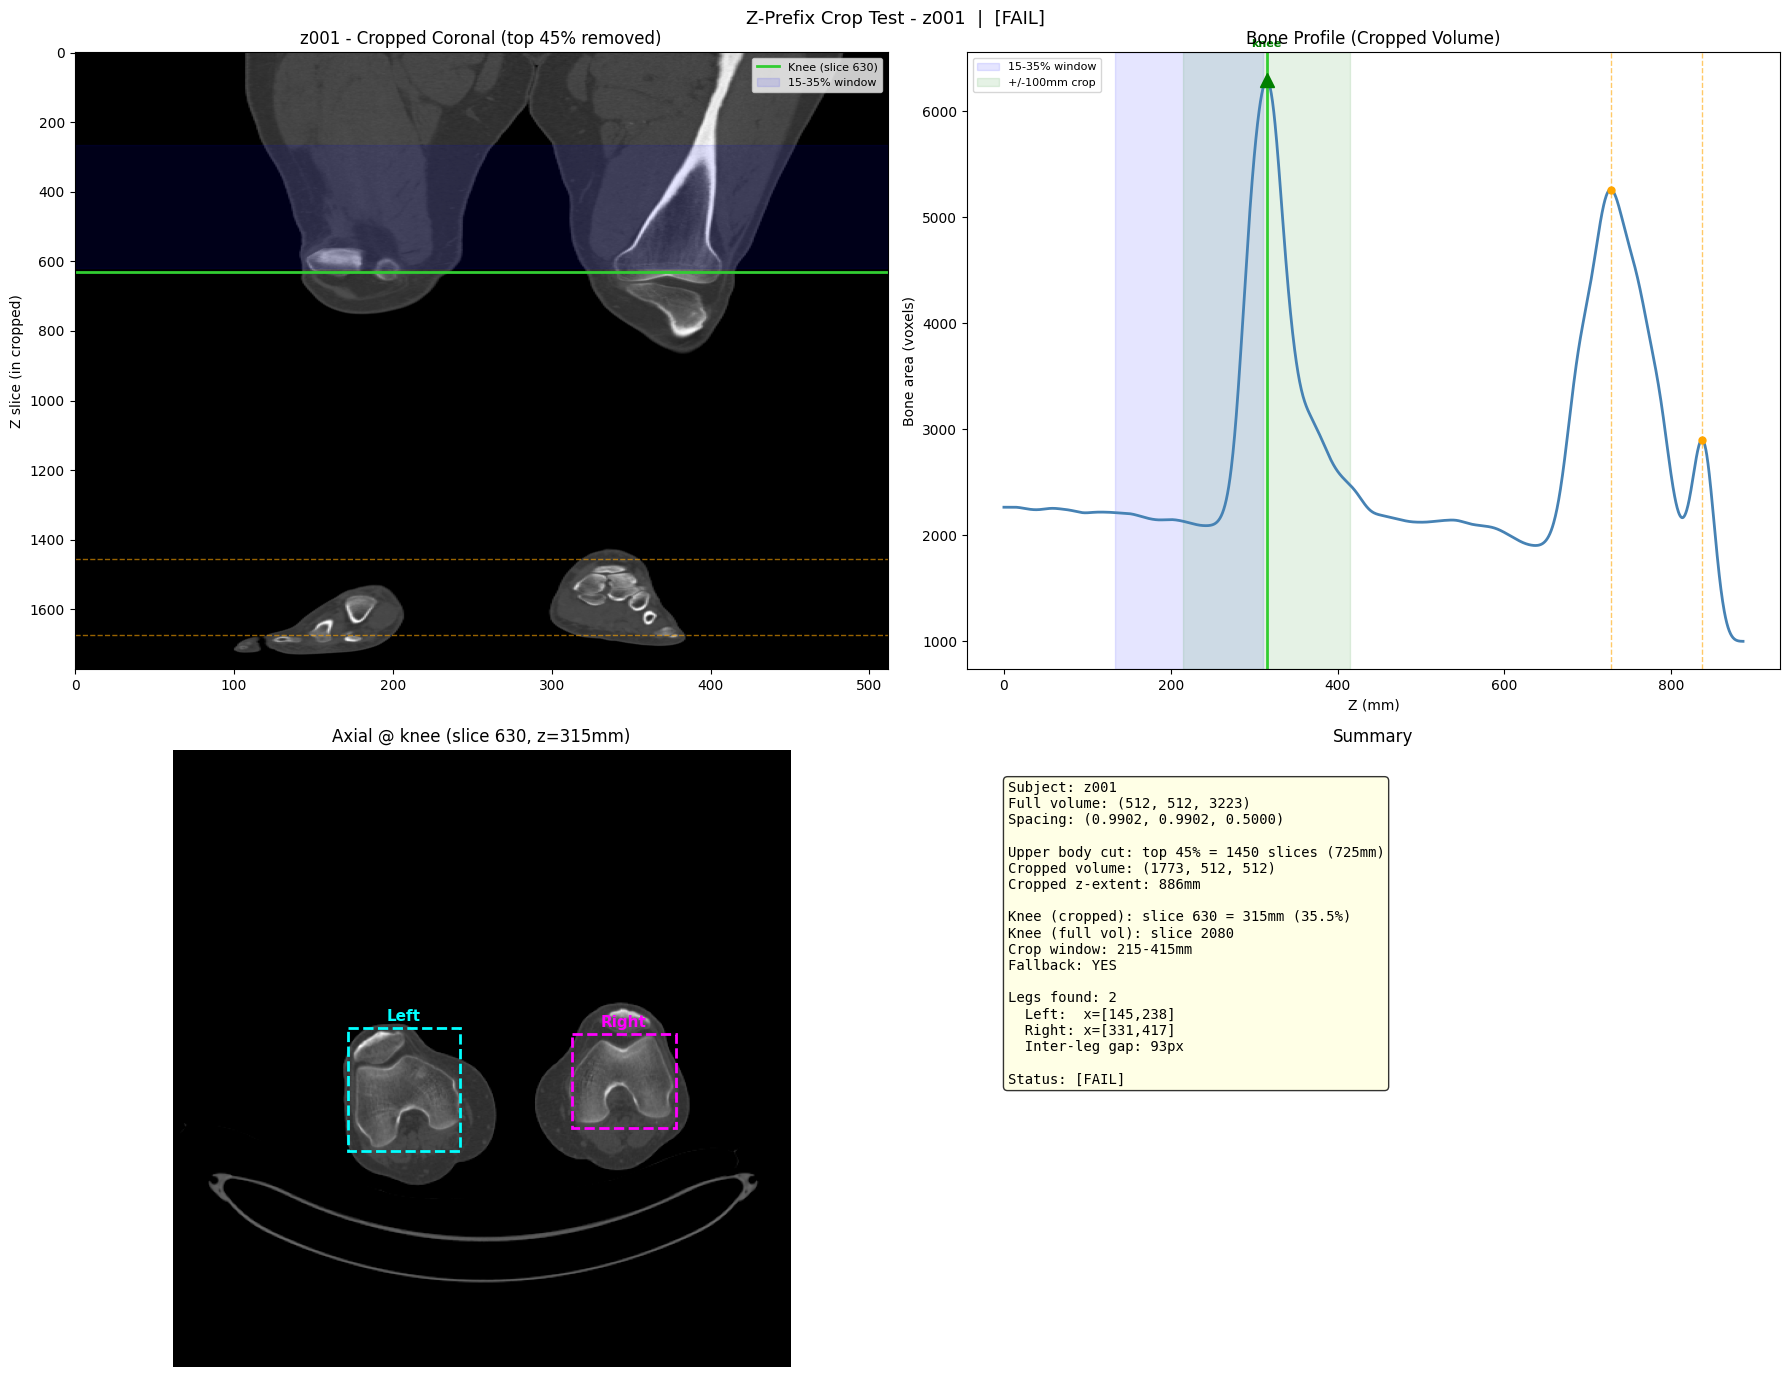

  Saved: c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\reports\figures\z_vsd_crop\z_z001_crop_test.png
Subject: z049
  Full volume: (3299, 512, 512), z-extent=1650mm
  Cropped: removed top 1484 slices (742mm)
  Cropped volume: (1815, 512, 512), z-extent=908mm
  Knee: slice 666 in cropped (333mm, 36.7%) [FALLBACK]
  Knee (full vol): slice 2150
  Legs: 2 found
    Left: x=[135,204] y=[228,307]
    Right: x=[314,385] y=[239,309]
  Inter-leg gap: 110px
  Status: [FAIL]


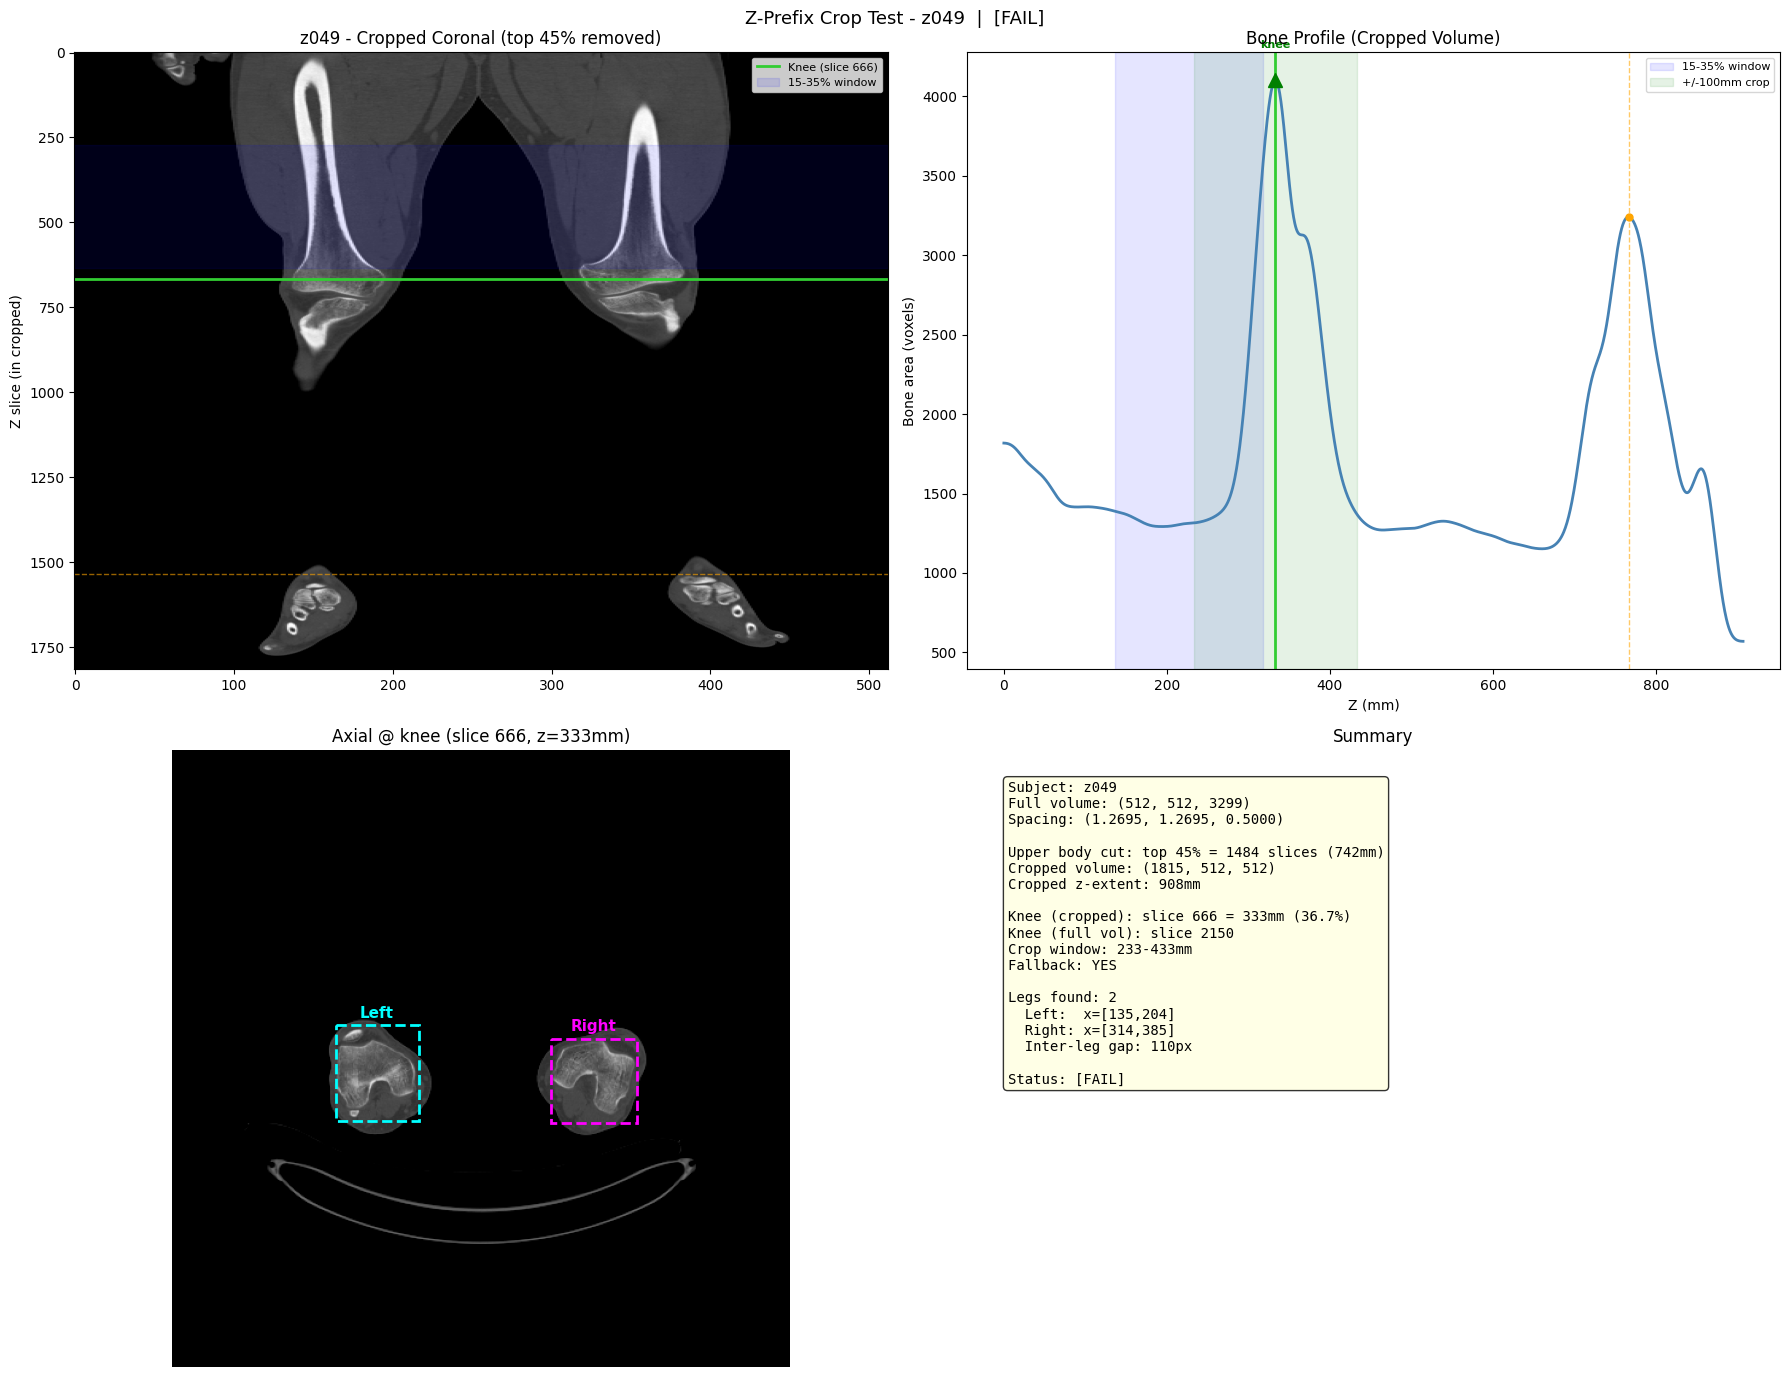

  Saved: c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\reports\figures\z_vsd_crop\z_z049_crop_test.png
Subject: z066
  Full volume: (3114, 512, 512), z-extent=1557mm
  Cropped: removed top 1401 slices (700mm)
  Cropped volume: (1713, 512, 512), z-extent=856mm
  Knee: slice 678 in cropped (339mm, 39.6%) [FALLBACK]
  Knee (full vol): slice 2079
  Legs: 2 found
    Left: x=[121,210] y=[241,317]
    Right: x=[289,380] y=[236,315]
  Inter-leg gap: 79px
  Status: [FAIL]


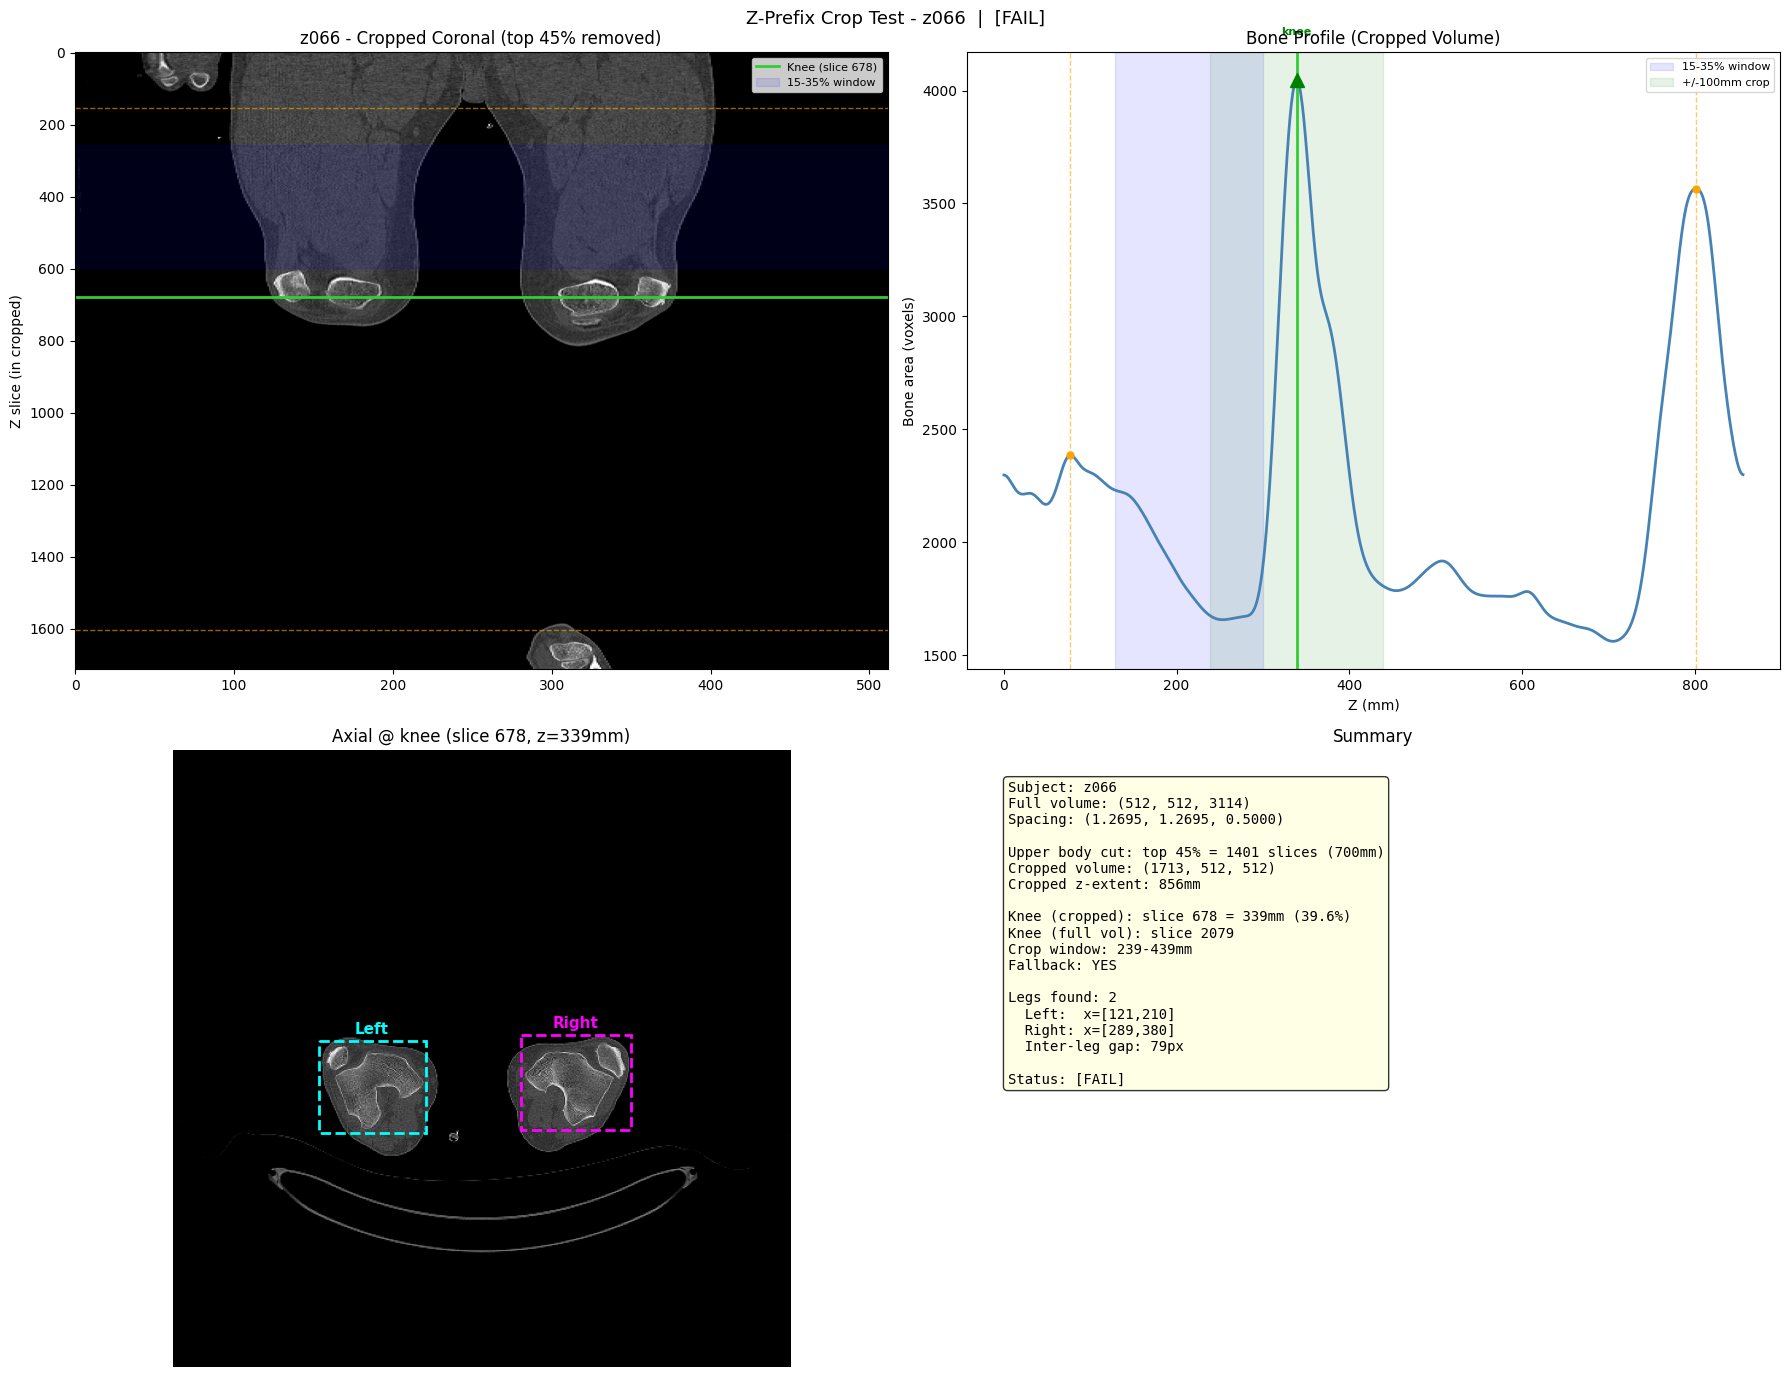

  Saved: c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\reports\figures\z_vsd_crop\z_z066_crop_test.png

Test Results:


,subject_id,cut_slice,cropped_z_mm,knee_slice_cropped,knee_slice_full,knee_z_mm,knee_pct_cropped,n_legs,inter_gap_px,fallback,status
0,z001,1450,886.5,630,2080,315.0,35.5,2,93,True,FAIL
1,z049,1484,907.5,666,2150,333.0,36.7,2,110,True,FAIL
2,z066,1401,856.5,678,2079,339.0,39.6,2,79,True,FAIL



Passed: 0/3


In [4]:
sample_indices = [0, len(z_cases) // 2, len(z_cases) - 1]
sample_cases = [z_cases[i] for i in sample_indices]

print(f"Testing on {len(sample_cases)} representative subjects:")
print(f"  {[c['subject_id'] for c in sample_cases]}\n")

test_results = []

for case in sample_cases:
    sid = case["subject_id"]
    spacing_z = case["spacing_z"]

    print(f"{'='*60}")
    print(f"Subject: {sid}")
    print(f"{'='*60}")

    # 1. Load full volume
    img = sitk.ReadImage(case["nii_path"])
    arr = sitk.GetArrayFromImage(img).astype(np.float32)
    print(f"  Full volume: {arr.shape}, z-extent={arr.shape[0]*spacing_z:.0f}mm")

    # 2. Crop upper body
    arr_cropped, cut_slice = crop_upper_body(arr)
    cropped_z_mm = arr_cropped.shape[0] * spacing_z
    print(f"  Cropped: removed top {cut_slice} slices ({cut_slice*spacing_z:.0f}mm)")
    print(f"  Cropped volume: {arr_cropped.shape}, z-extent={cropped_z_mm:.0f}mm")

    # 3. Find knee in cropped volume
    knee_slice_c, z_mm_c, smoothed_c, peaks_c, fallback = find_knee_in_cropped(
        arr_cropped, spacing_z
    )
    knee_z_mm = float(z_mm_c[knee_slice_c])
    knee_pct = 100.0 * knee_z_mm / cropped_z_mm
    knee_slice_full = knee_slice_c + cut_slice

    fb_tag = " [FALLBACK]" if fallback else ""
    print(f"  Knee: slice {knee_slice_c} in cropped ({knee_z_mm:.0f}mm, {knee_pct:.1f}%){fb_tag}")
    print(f"  Knee (full vol): slice {knee_slice_full}")

    # 4. Bilateral leg separation
    sep_status = "PASS"
    legs = []
    try:
        legs, labeled, bone_closed = separate_legs_cc(arr_cropped, knee_slice_c, case["spacing_x"])
        print(f"  Legs: {len(legs)} found")
        for leg in legs:
            print(f"    {leg['side']}: x=[{leg['x_min']},{leg['x_max']}] "
                  f"y=[{leg['y_min']},{leg['y_max']}]")
        inter_gap = legs[1]["x_min"] - legs[0]["x_max"] if len(legs) == 2 else None
        if inter_gap is not None:
            print(f"  Inter-leg gap: {inter_gap}px")
    except ValueError as e:
        print(f"  Legs: FAIL - {e}")
        inter_gap = None
        sep_status = "FAIL"

    status = "PASS" if sep_status == "PASS" and not fallback else "FAIL"
    print(f"  Status: [{status}]")

    test_results.append({
        "subject_id": sid, "cut_slice": cut_slice,
        "cropped_z_mm": round(cropped_z_mm, 1),
        "knee_slice_cropped": knee_slice_c, "knee_slice_full": knee_slice_full,
        "knee_z_mm": round(knee_z_mm, 1), "knee_pct_cropped": round(knee_pct, 1),
        "n_legs": len(legs), "inter_gap_px": inter_gap,
        "fallback": fallback, "status": status,
    })

    # ── 4-panel diagnostic figure ─────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    # Panel 1: Coronal view of cropped volume
    mid_y = arr_cropped.shape[1] // 2
    coronal = arr_cropped[:, mid_y, :]
    axes[0, 0].imshow(coronal, cmap="gray", vmin=-500, vmax=1500, aspect="auto")
    axes[0, 0].axhline(y=knee_slice_c, color="limegreen", linewidth=2,
                        label=f"Knee (slice {knee_slice_c})")
    lo_s = int(KNEE_Z_RANGE[0] * arr_cropped.shape[0])
    hi_s = int(KNEE_Z_RANGE[1] * arr_cropped.shape[0])
    axes[0, 0].axhspan(lo_s, hi_s, alpha=0.1, color="blue", label="15-35% window")
    for p in peaks_c:
        if p != knee_slice_c:
            axes[0, 0].axhline(y=p, color="orange", linewidth=1, linestyle="--", alpha=0.6)
    axes[0, 0].set_title(f"{sid} - Cropped Coronal (top {Z_CROP_TOP_PCT*100:.0f}% removed)")
    axes[0, 0].set_ylabel("Z slice (in cropped)")
    axes[0, 0].legend(loc="upper right", fontsize=8)

    # Panel 2: Bone profile
    axes[0, 1].plot(z_mm_c, smoothed_c, color="steelblue", linewidth=2)
    lo_mm = cropped_z_mm * KNEE_Z_RANGE[0]
    hi_mm = cropped_z_mm * KNEE_Z_RANGE[1]
    axes[0, 1].axvspan(lo_mm, hi_mm, alpha=0.1, color="blue", label="15-35% window")
    for p in peaks_c:
        if p == knee_slice_c:
            axes[0, 1].axvline(x=z_mm_c[p], color="limegreen", linewidth=2)
            axes[0, 1].plot(z_mm_c[p], smoothed_c[p], "g^", markersize=10)
            axes[0, 1].text(z_mm_c[p], smoothed_c[p] * 1.05, "knee",
                            color="green", fontsize=8, ha="center", fontweight="bold")
        else:
            axes[0, 1].axvline(x=z_mm_c[p], color="orange", linewidth=1, linestyle="--", alpha=0.6)
            axes[0, 1].plot(z_mm_c[p], smoothed_c[p], "o", color="orange", markersize=5)
    axes[0, 1].axvspan(max(0, knee_z_mm - KNEE_CROP_MARGIN_MM),
                       min(cropped_z_mm, knee_z_mm + KNEE_CROP_MARGIN_MM),
                       alpha=0.1, color="green", label="+/-100mm crop")
    axes[0, 1].set_title("Bone Profile (Cropped Volume)")
    axes[0, 1].set_xlabel("Z (mm)")
    axes[0, 1].set_ylabel("Bone area (voxels)")
    axes[0, 1].legend(fontsize=8)

    # Panel 3: Axial slice at knee with CC bounding boxes
    axial = arr_cropped[knee_slice_c]
    axes[1, 0].imshow(axial, cmap="gray", vmin=-500, vmax=1500)
    for leg in legs:
        color = "cyan" if leg["side"] == "Left" else "magenta"
        rect = mpatches.Rectangle(
            (leg["x_min"], leg["y_min"]),
            leg["x_max"] - leg["x_min"], leg["y_max"] - leg["y_min"],
            linewidth=2, edgecolor=color, facecolor="none", linestyle="--")
        axes[1, 0].add_patch(rect)
        axes[1, 0].text(leg["x_center"], leg["y_min"] - 6, leg["side"],
                        color=color, fontsize=11, ha="center", fontweight="bold")
    axes[1, 0].set_title(f"Axial @ knee (slice {knee_slice_c}, z={knee_z_mm:.0f}mm)")
    axes[1, 0].axis("off")

    # Panel 4: Info panel
    axes[1, 1].axis("off")
    info = "\n".join([
        f"Subject: {sid}",
        f"Full volume: {case['size_xyz']}",
        f"Spacing: ({case['spacing_x']:.4f}, {case['spacing_y']:.4f}, {case['spacing_z']:.4f})",
        "",
        f"Upper body cut: top {Z_CROP_TOP_PCT*100:.0f}% = {cut_slice} slices "
        f"({cut_slice*spacing_z:.0f}mm)",
        f"Cropped volume: {arr_cropped.shape}",
        f"Cropped z-extent: {cropped_z_mm:.0f}mm",
        "",
        f"Knee (cropped): slice {knee_slice_c} = {knee_z_mm:.0f}mm ({knee_pct:.1f}%)",
        f"Knee (full vol): slice {knee_slice_full}",
        f"Crop window: {max(0,knee_z_mm-100):.0f}-{min(cropped_z_mm,knee_z_mm+100):.0f}mm",
        f"Fallback: {'YES' if fallback else 'No'}",
        "",
        f"Legs found: {len(legs)}",
    ] + ([f"  Left:  x=[{legs[0]['x_min']},{legs[0]['x_max']}]",
          f"  Right: x=[{legs[1]['x_min']},{legs[1]['x_max']}]",
          f"  Inter-leg gap: {inter_gap}px"] if len(legs) == 2 else [])
    + ["", f"Status: [{status}]"])
    axes[1, 1].text(0.05, 0.95, info, transform=axes[1, 1].transAxes,
                    fontsize=10, verticalalignment="top", fontfamily="monospace",
                    bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
    axes[1, 1].set_title("Summary")

    plt.suptitle(f"Z-Prefix Crop Test - {sid}  |  [{status}]", fontsize=13)
    plt.tight_layout()
    fig_path = FIG_DIR / f"z_{sid}_crop_test.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {fig_path}")

    del arr, arr_cropped, img, coronal
    gc.collect()

print(f"\n{'='*60}")
print("Test Results:")
df_test = pd.DataFrame(test_results)
display(df_test)
n_pass = sum(1 for r in test_results if r["status"] == "PASS")
print(f"\nPassed: {n_pass}/{len(test_results)}")

## 4b — Robustness Validation: Empirical Knee Position Distribution

The 3-subject test above shows the knee consistently falls at **35-40%** of the
cropped volume — just outside the current 15-35% search window.

**This cell answers two questions:**
1. Where do the knee peaks actually cluster across all 20 subjects?
2. Does bilateral separation work at every detected knee position?

We use a deliberately **wide search range (5-60%)** to avoid any boundary bias,
then plot the empirical distribution to determine the optimal tight range.

Scanning all 20 subjects with wide range (5-60%)...

  [ 1/20] z001: knee= 35.5%  (  315mm)  [OUT]  2-legs  gap=93
  [ 2/20] z004: knee= 34.0%  (  303mm)  [IN ]  2-legs  gap=74
  [ 3/20] z009: knee= 36.3%  (  322mm)  [OUT]  2-legs  gap=77
  [ 4/20] z013: knee= 31.4%  (  269mm)  [IN ]  2-legs  gap=60
  [ 5/20] z023: knee= 36.5%  (  314mm)  [OUT]  2-legs  gap=251
  [ 6/20] z027: knee= 35.4%  (  312mm)  [OUT]  2-legs  gap=55
  [ 7/20] z035: knee= 35.9%  (  304mm)  [OUT]  2-legs  gap=79
  [ 8/20] z036: knee= 36.1%  (  336mm)  [OUT]  2-legs  gap=3
  [ 9/20] z042: knee= 36.4%  (  306mm)  [OUT]  2-legs  gap=58
  [10/20] z046: knee= 37.2%  (  336mm)  [OUT]  2-legs  gap=122
  [11/20] z049: knee= 36.7%  (  333mm)  [OUT]  2-legs  gap=110
  [12/20] z050: knee= 36.9%  (  305mm)  [OUT]  2-legs  gap=63
  [13/20] z055: knee= 38.1%  (  334mm)  [OUT]  2-legs  gap=57
  [14/20] z056: knee= 34.6%  (  330mm)  [IN ]  2-legs  gap=59
  [15/20] z057: knee= 36.3%  (  321mm)  [OUT]  2-legs  gap=188
  [16/20] z061

,subject_id,cropped_z_mm,knee_z_mm,knee_pct,n_peaks,all_peak_pcts,in_15_35,n_legs,inter_gap_px,sep_ok
0,z001,886.5,315.0,35.5,3,"36%, 82%, 94%",False,2,93,True
1,z004,890.0,303.0,34.0,2,"34%, 87%",True,2,74,True
2,z009,888.0,322.5,36.3,2,"36%, 82%",False,2,77,True
3,z013,856.5,269.0,31.4,2,"31%, 74%",True,2,60,True
4,z023,859.0,313.5,36.5,2,"36%, 80%",False,2,251,True
5,z027,882.5,312.0,35.4,2,"35%, 80%",False,2,55,True
6,z035,848.0,304.5,35.9,2,"36%, 81%",False,2,79,True
7,z036,930.5,335.5,36.1,2,"36%, 82%",False,2,3,True
8,z042,840.0,305.5,36.4,2,"36%, 86%",False,2,58,True
9,z046,902.6,336.0,37.2,3,"37%, 81%, 85%",False,2,122,True


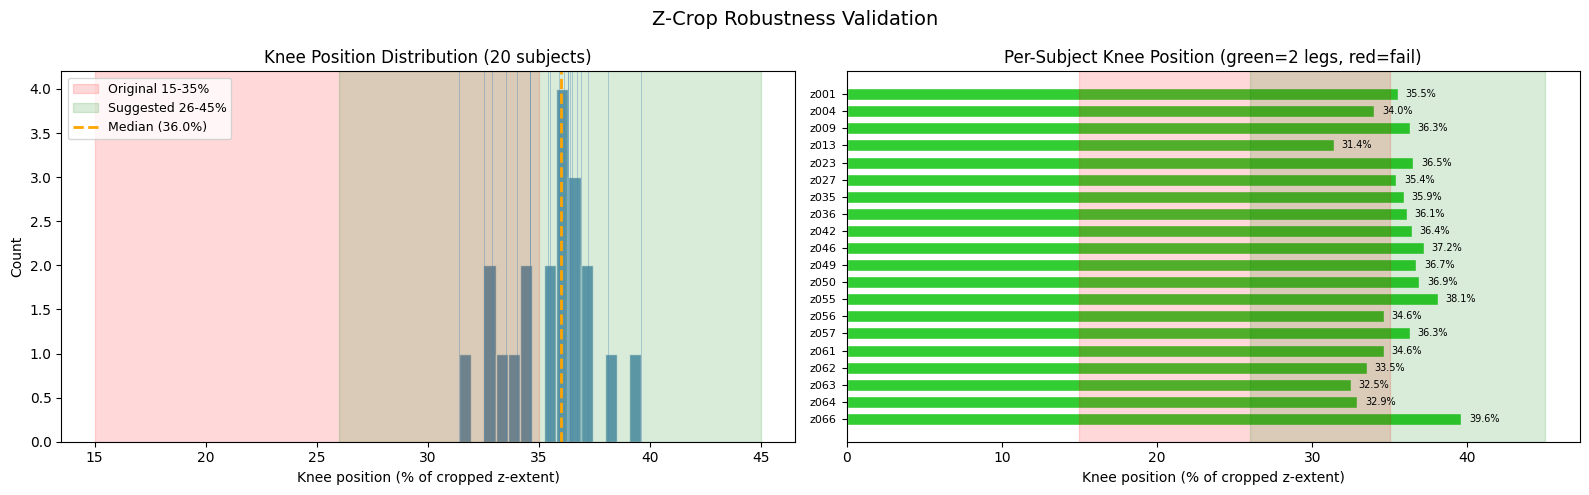


Figure saved: c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\reports\figures\z_vsd_crop\z_crop_robustness_validation.png


In [5]:
# ── Robustness validation: wide-range knee scan across all 20 subjects ───────
# Uses a deliberately wide 5-60% range to avoid boundary bias.
# For each subject: crop upper body, find ALL peaks, pick knee from wide range,
# test bilateral separation, record empirical knee position.

WIDE_RANGE = (0.05, 0.60)  # permissive range for validation only

validation_rows = []

print(f"Scanning all {len(z_cases)} subjects with wide range "
      f"({WIDE_RANGE[0]*100:.0f}-{WIDE_RANGE[1]*100:.0f}%)...\n")

for idx, case in enumerate(z_cases):
    sid = case["subject_id"]
    spacing_z = case["spacing_z"]

    # Load and crop
    img = sitk.ReadImage(case["nii_path"])
    arr = sitk.GetArrayFromImage(img).astype(np.float32)
    arr_cropped, cut_slice = crop_upper_body(arr)
    n_slices_cropped = arr_cropped.shape[0]
    cropped_z_mm = n_slices_cropped * spacing_z

    # Bone profile + peaks
    bone_area = (arr_cropped > BONE_HU_THRESHOLD).sum(axis=(1, 2)).astype(float)
    smoothed = gaussian_filter1d(bone_area, sigma=PROFILE_SMOOTH_SIGMA)
    peaks, props = find_peaks(
        smoothed,
        height=np.max(smoothed) * PEAK_MIN_HEIGHT_FRAC,
        distance=PEAK_MIN_DISTANCE,
        prominence=np.max(smoothed) * 0.05,
    )
    z_mm = np.arange(len(bone_area)) * spacing_z
    total_z = float(z_mm[-1])

    # Find knee using WIDE range
    lo_w = total_z * WIDE_RANGE[0]
    hi_w = total_z * WIDE_RANGE[1]
    wide_candidates = [p for p in peaks if lo_w <= z_mm[p] <= hi_w]

    if wide_candidates:
        knee_slice = max(wide_candidates, key=lambda p: smoothed[p])
        knee_found = True
    else:
        # Ultimate fallback: peak closest to 30%
        target = total_z * 0.30
        knee_slice = min(peaks, key=lambda p: abs(z_mm[p] - target))
        knee_found = False

    knee_z_mm = float(z_mm[knee_slice])
    knee_pct = 100.0 * knee_z_mm / cropped_z_mm

    # All peak positions as percentages (for context)
    all_peak_pcts = [100.0 * z_mm[p] / cropped_z_mm for p in peaks]

    # Test bilateral separation at this knee position
    n_legs = 0
    inter_gap = None
    sep_ok = False
    try:
        legs, _, _ = separate_legs_cc(arr_cropped, knee_slice, case["spacing_x"])
        n_legs = len(legs)
        inter_gap = legs[1]["x_min"] - legs[0]["x_max"] if n_legs == 2 else None
        sep_ok = (n_legs == 2)
    except ValueError:
        pass

    # Check if the original 15-35% range would have caught this knee
    lo_orig = total_z * KNEE_Z_RANGE[0]
    hi_orig = total_z * KNEE_Z_RANGE[1]
    in_original_range = lo_orig <= knee_z_mm <= hi_orig

    validation_rows.append({
        "subject_id": sid,
        "cropped_z_mm": round(cropped_z_mm, 1),
        "knee_z_mm": round(knee_z_mm, 1),
        "knee_pct": round(knee_pct, 1),
        "n_peaks": len(peaks),
        "all_peak_pcts": ", ".join(f"{p:.0f}%" for p in all_peak_pcts),
        "in_15_35": in_original_range,
        "n_legs": n_legs,
        "inter_gap_px": inter_gap,
        "sep_ok": sep_ok,
    })

    tag = "IN" if in_original_range else "OUT"
    sep_tag = "2-legs" if sep_ok else "FAIL"
    print(f"  [{idx+1:2d}/20] {sid}: knee={knee_pct:5.1f}%  "
          f"({knee_z_mm:5.0f}mm)  [{tag:3s}]  {sep_tag}  "
          f"gap={inter_gap}")

    del arr, arr_cropped, img
    gc.collect()

# ── Summary ──────────────────────────────────────────────────────────────────
df_val = pd.DataFrame(validation_rows)

print(f"\n{'='*70}")
print("EMPIRICAL KNEE POSITION DISTRIBUTION")
print(f"{'='*70}")

pcts = df_val["knee_pct"].values
print(f"  Min:    {pcts.min():.1f}%")
print(f"  Max:    {pcts.max():.1f}%")
print(f"  Mean:   {pcts.mean():.1f}%")
print(f"  Median: {np.median(pcts):.1f}%")
print(f"  Std:    {pcts.std():.1f}%")
print(f"\n  In original 15-35% range: {df_val['in_15_35'].sum()}/{len(df_val)}")
print(f"  Bilateral separation OK:  {df_val['sep_ok'].sum()}/{len(df_val)}")

# Suggest an optimal range with 5% margin on each side
suggested_lo = max(5.0, np.floor(pcts.min() - 5.0))
suggested_hi = min(60.0, np.ceil(pcts.max() + 5.0))
print(f"\n  SUGGESTED RANGE: {suggested_lo:.0f}-{suggested_hi:.0f}%")
print(f"  (empirical [{pcts.min():.1f}%, {pcts.max():.1f}%] + 5% margin each side)")

display(df_val)

# ── Distribution plot ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Histogram of knee positions
axes[0].hist(pcts, bins=15, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvspan(15, 35, alpha=0.15, color="red", label="Original 15-35%")
axes[0].axvspan(suggested_lo, suggested_hi, alpha=0.15, color="green",
                label=f"Suggested {suggested_lo:.0f}-{suggested_hi:.0f}%")
axes[0].axvline(x=np.median(pcts), color="orange", linewidth=2, linestyle="--",
                label=f"Median ({np.median(pcts):.1f}%)")
for p in pcts:
    axes[0].axvline(x=p, color="steelblue", linewidth=0.5, alpha=0.5)
axes[0].set_xlabel("Knee position (% of cropped z-extent)")
axes[0].set_ylabel("Count")
axes[0].set_title("Knee Position Distribution (20 subjects)")
axes[0].legend(fontsize=9)

# Panel 2: Subject-by-subject knee position with separation status
colors = ["limegreen" if ok else "red" for ok in df_val["sep_ok"]]
axes[1].barh(range(len(df_val)), pcts, color=colors, edgecolor="white", height=0.7)
axes[1].axvspan(15, 35, alpha=0.15, color="red")
axes[1].axvspan(suggested_lo, suggested_hi, alpha=0.15, color="green")
axes[1].set_yticks(range(len(df_val)))
axes[1].set_yticklabels(df_val["subject_id"], fontsize=8)
axes[1].set_xlabel("Knee position (% of cropped z-extent)")
axes[1].set_title("Per-Subject Knee Position (green=2 legs, red=fail)")
axes[1].invert_yaxis()

# Add percentage labels
for i, p in enumerate(pcts):
    axes[1].text(p + 0.5, i, f"{p:.1f}%", va="center", fontsize=7)

plt.suptitle("Z-Crop Robustness Validation", fontsize=14)
plt.tight_layout()
fig_path = FIG_DIR / "z_crop_robustness_validation.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nFigure saved: {fig_path}")

## 4c — Update Parameters & Retest

Based on the empirical distribution above, update `KNEE_Z_RANGE` to cover
all observed knee positions with margin, then re-run the 3-subject test
to confirm the updated range eliminates false-FAIL results.

In [6]:
# ── Update KNEE_Z_RANGE based on empirical validation ────────────────────────
# The validation cell above found the empirical knee position range.
# We set the search range to [suggested_lo, suggested_hi] from the validation.

OLD_RANGE = KNEE_Z_RANGE
NEW_LO = suggested_lo / 100.0
NEW_HI = suggested_hi / 100.0
KNEE_Z_RANGE = (NEW_LO, NEW_HI)
KNEE_FALLBACK_PCT = round((NEW_LO + NEW_HI) / 2, 2)  # midpoint of new range

print(f"KNEE_Z_RANGE updated: {OLD_RANGE} -> {KNEE_Z_RANGE}")
print(f"KNEE_FALLBACK_PCT updated -> {KNEE_FALLBACK_PCT}")
print(f"  (covers empirical range [{pcts.min():.1f}%, {pcts.max():.1f}%] "
      f"with 5% margin each side)\n")

# ── Re-define find_knee_in_cropped() with updated range ──────────────────────
def find_knee_in_cropped(arr_cropped, spacing_z):
    """Find knee center in a lower-body sub-volume (updated range)."""
    bone_area = (arr_cropped > BONE_HU_THRESHOLD).sum(axis=(1, 2)).astype(float)
    smoothed = gaussian_filter1d(bone_area, sigma=PROFILE_SMOOTH_SIGMA)
    peaks, _ = find_peaks(
        smoothed,
        height=np.max(smoothed) * PEAK_MIN_HEIGHT_FRAC,
        distance=PEAK_MIN_DISTANCE,
        prominence=np.max(smoothed) * 0.05,
    )
    z_mm = np.arange(len(bone_area)) * spacing_z
    total_z = float(z_mm[-1])
    lo = total_z * KNEE_Z_RANGE[0]
    hi = total_z * KNEE_Z_RANGE[1]
    candidates = [p for p in peaks if lo <= z_mm[p] <= hi]
    if candidates:
        knee_slice = max(candidates, key=lambda p: smoothed[p])
        used_fallback = False
    else:
        target = total_z * KNEE_FALLBACK_PCT
        knee_slice = min(peaks, key=lambda p: abs(z_mm[p] - target))
        used_fallback = True
    return int(knee_slice), z_mm, smoothed, peaks, used_fallback

print("find_knee_in_cropped() re-defined with updated KNEE_Z_RANGE.")

# ── Quick retest on same 3 subjects ─────────────────────────────────────────
print(f"\nRetesting on {[c['subject_id'] for c in sample_cases]}...\n")
retest_results = []

for case in sample_cases:
    sid = case["subject_id"]
    spacing_z = case["spacing_z"]

    img = sitk.ReadImage(case["nii_path"])
    arr = sitk.GetArrayFromImage(img).astype(np.float32)
    arr_cropped, cut_slice = crop_upper_body(arr)
    cropped_z_mm = arr_cropped.shape[0] * spacing_z

    knee_slice_c, z_mm_c, smoothed_c, peaks_c, fallback = find_knee_in_cropped(
        arr_cropped, spacing_z
    )
    knee_z_mm = float(z_mm_c[knee_slice_c])
    knee_pct = 100.0 * knee_z_mm / cropped_z_mm

    legs = []
    sep_ok = False
    inter_gap = None
    try:
        legs, _, _ = separate_legs_cc(arr_cropped, knee_slice_c, case["spacing_x"])
        sep_ok = (len(legs) == 2)
        inter_gap = legs[1]["x_min"] - legs[0]["x_max"] if sep_ok else None
    except ValueError:
        pass

    status = "PASS" if sep_ok and not fallback else "FAIL"
    fb = " [FALLBACK]" if fallback else ""
    print(f"  {sid}: knee={knee_pct:.1f}%, legs={len(legs)}, "
          f"gap={inter_gap}, [{status}]{fb}")

    retest_results.append({
        "subject_id": sid, "knee_pct": round(knee_pct, 1),
        "fallback": fallback, "n_legs": len(legs),
        "inter_gap_px": inter_gap, "status": status,
    })

    del arr, arr_cropped, img
    gc.collect()

df_retest = pd.DataFrame(retest_results)
display(df_retest)

n_pass = sum(1 for r in retest_results if r["status"] == "PASS")
print(f"\nRetest passed: {n_pass}/{len(retest_results)}")
if n_pass == len(retest_results):
    print("All subjects PASS with updated range. Proceed to Cell 5 (full run).")

KNEE_Z_RANGE updated: (0.15, 0.35) -> (np.float64(0.26), np.float64(0.45))
KNEE_FALLBACK_PCT updated -> 0.36
  (covers empirical range [31.4%, 39.6%] with 5% margin each side)

find_knee_in_cropped() re-defined with updated KNEE_Z_RANGE.

Retesting on ['z001', 'z049', 'z066']...

  z001: knee=35.5%, legs=2, gap=93, [PASS]
  z049: knee=36.7%, legs=2, gap=110, [PASS]
  z066: knee=39.6%, legs=2, gap=79, [PASS]


,subject_id,knee_pct,fallback,n_legs,inter_gap_px,status
0,z001,35.5,False,2,93,PASS
1,z049,36.7,False,2,110,PASS
2,z066,39.6,False,2,79,PASS



Retest passed: 3/3
All subjects PASS with updated range. Proceed to Cell 5 (full run).


## 5 — Process All 20 Subjects

Run the pipeline on every z-prefix subject. Save per-subject diagnostic figures
and collect results in a summary table.

In [7]:
print(f"Processing all {len(z_cases)} z-prefix subjects...\n")

all_results = []

for idx, case in enumerate(z_cases):
    sid = case["subject_id"]
    spacing_z = case["spacing_z"]
    print(f"[{idx+1}/{len(z_cases)}] {sid}...", end=" ")

    # Load, crop, find knee, separate legs
    img = sitk.ReadImage(case["nii_path"])
    arr = sitk.GetArrayFromImage(img).astype(np.float32)
    arr_cropped, cut_slice = crop_upper_body(arr)
    cropped_z_mm = arr_cropped.shape[0] * spacing_z

    knee_slice_c, z_mm_c, smoothed_c, peaks_c, fallback = find_knee_in_cropped(
        arr_cropped, spacing_z
    )
    knee_z_mm = float(z_mm_c[knee_slice_c])
    knee_pct = 100.0 * knee_z_mm / cropped_z_mm
    knee_slice_full = knee_slice_c + cut_slice

    legs = []
    inter_gap = None
    sep_status = "PASS"
    try:
        legs, labeled, bone_closed = separate_legs_cc(arr_cropped, knee_slice_c, case["spacing_x"])
        inter_gap = legs[1]["x_min"] - legs[0]["x_max"] if len(legs) == 2 else None
    except ValueError as e:
        sep_status = "FAIL"

    status = "PASS" if sep_status == "PASS" and not fallback else "FAIL"

    all_results.append({
        "subject_id": sid, "cut_slice": cut_slice,
        "cropped_z_mm": round(cropped_z_mm, 1),
        "knee_slice_cropped": knee_slice_c, "knee_slice_full": knee_slice_full,
        "knee_z_mm": round(knee_z_mm, 1), "knee_pct_cropped": round(knee_pct, 1),
        "n_legs": len(legs), "inter_gap_px": inter_gap,
        "fallback": fallback, "status": status,
        "legs": legs,  # keep for Cell 6 (crop & save)
    })

    # Save compact diagnostic figure (same 4-panel layout)
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    mid_y = arr_cropped.shape[1] // 2
    coronal = arr_cropped[:, mid_y, :]
    axes[0, 0].imshow(coronal, cmap="gray", vmin=-500, vmax=1500, aspect="auto")
    axes[0, 0].axhline(y=knee_slice_c, color="limegreen", linewidth=2)
    lo_s = int(KNEE_Z_RANGE[0] * arr_cropped.shape[0])
    hi_s = int(KNEE_Z_RANGE[1] * arr_cropped.shape[0])
    axes[0, 0].axhspan(lo_s, hi_s, alpha=0.1, color="blue")
    for p in peaks_c:
        if p != knee_slice_c:
            axes[0, 0].axhline(y=p, color="orange", linewidth=1, linestyle="--", alpha=0.6)
    axes[0, 0].set_title(f"{sid} - Cropped Coronal")
    axes[0, 0].set_ylabel("Z slice")

    axes[0, 1].plot(z_mm_c, smoothed_c, color="steelblue", linewidth=2)
    lo_mm = cropped_z_mm * KNEE_Z_RANGE[0]
    hi_mm = cropped_z_mm * KNEE_Z_RANGE[1]
    axes[0, 1].axvspan(lo_mm, hi_mm, alpha=0.1, color="blue")
    for p in peaks_c:
        if p == knee_slice_c:
            axes[0, 1].axvline(x=z_mm_c[p], color="limegreen", linewidth=2)
            axes[0, 1].plot(z_mm_c[p], smoothed_c[p], "g^", markersize=10)
        else:
            axes[0, 1].axvline(x=z_mm_c[p], color="orange", linewidth=1, linestyle="--", alpha=0.6)
    axes[0, 1].axvspan(max(0, knee_z_mm - 100), min(cropped_z_mm, knee_z_mm + 100),
                       alpha=0.1, color="green")
    axes[0, 1].set_title("Bone Profile")
    axes[0, 1].set_xlabel("Z (mm)")

    axial = arr_cropped[knee_slice_c]
    axes[1, 0].imshow(axial, cmap="gray", vmin=-500, vmax=1500)
    for leg in legs:
        color = "cyan" if leg["side"] == "Left" else "magenta"
        rect = mpatches.Rectangle(
            (leg["x_min"], leg["y_min"]),
            leg["x_max"] - leg["x_min"], leg["y_max"] - leg["y_min"],
            linewidth=2, edgecolor=color, facecolor="none", linestyle="--")
        axes[1, 0].add_patch(rect)
        axes[1, 0].text(leg["x_center"], leg["y_min"] - 6, leg["side"],
                        color=color, fontsize=11, ha="center", fontweight="bold")
    axes[1, 0].set_title(f"Axial @ knee z={knee_z_mm:.0f}mm")
    axes[1, 0].axis("off")

    axes[1, 1].axis("off")
    info = (f"Knee: {knee_z_mm:.0f}mm ({knee_pct:.1f}% of cropped)\n"
            f"Legs: {len(legs)}  Gap: {inter_gap}px\n"
            f"Fallback: {'YES' if fallback else 'No'}\n"
            f"Status: [{status}]")
    axes[1, 1].text(0.5, 0.5, info, transform=axes[1, 1].transAxes, fontsize=12,
                    ha="center", va="center", fontfamily="monospace",
                    bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

    plt.suptitle(f"{sid}  |  [{status}]", fontsize=13)
    plt.tight_layout()
    fig_path = FIG_DIR / f"z_{sid}_crop_test.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    fb = " [FB]" if fallback else ""
    print(f"knee={knee_z_mm:.0f}mm ({knee_pct:.1f}%), legs={len(legs)}, [{status}]{fb}")

    del arr, arr_cropped, img, coronal
    gc.collect()

# Summary table
print(f"\n{'='*60}")
print("Summary:")
df_all = pd.DataFrame([{k: v for k, v in r.items() if k != "legs"} for r in all_results])
display(df_all)

n_pass = sum(1 for r in all_results if r["status"] == "PASS")
n_fb = sum(1 for r in all_results if r["fallback"])
print(f"\nPassed: {n_pass}/{len(all_results)}")
print(f"Fallback triggered: {n_fb}/{len(all_results)}")
if n_pass > 0:
    passing = [r for r in all_results if r["status"] == "PASS"]
    print(f"Knee z-range (passing): "
          f"{min(r['knee_z_mm'] for r in passing):.0f}-"
          f"{max(r['knee_z_mm'] for r in passing):.0f}mm")
    print(f"Knee % range (passing): "
          f"{min(r['knee_pct_cropped'] for r in passing):.1f}-"
          f"{max(r['knee_pct_cropped'] for r in passing):.1f}%")
print(f"\nDiagnostic figures saved to: {FIG_DIR}")

Processing all 20 z-prefix subjects...

[1/20] z001... knee=315mm (35.5%), legs=2, [PASS]
[2/20] z004... knee=303mm (34.0%), legs=2, [PASS]
[3/20] z009... knee=322mm (36.3%), legs=2, [PASS]
[4/20] z013... knee=269mm (31.4%), legs=2, [PASS]
[5/20] z023... knee=314mm (36.5%), legs=2, [PASS]
[6/20] z027... knee=312mm (35.4%), legs=2, [PASS]
[7/20] z035... knee=304mm (35.9%), legs=2, [PASS]
[8/20] z036... knee=336mm (36.1%), legs=2, [PASS]
[9/20] z042... knee=306mm (36.4%), legs=2, [PASS]
[10/20] z046... knee=336mm (37.2%), legs=2, [PASS]
[11/20] z049... knee=333mm (36.7%), legs=2, [PASS]
[12/20] z050... knee=305mm (36.9%), legs=2, [PASS]
[13/20] z055... knee=334mm (38.1%), legs=2, [PASS]
[14/20] z056... knee=330mm (34.6%), legs=2, [PASS]
[15/20] z057... knee=321mm (36.3%), legs=2, [PASS]
[16/20] z061... knee=312mm (34.6%), legs=2, [PASS]
[17/20] z062... knee=296mm (33.5%), legs=2, [PASS]
[18/20] z063... knee=286mm (32.5%), legs=2, [PASS]
[19/20] z064... knee=292mm (32.9%), legs=2, [PASS]


,subject_id,cut_slice,cropped_z_mm,knee_slice_cropped,knee_slice_full,knee_z_mm,knee_pct_cropped,n_legs,inter_gap_px,fallback,status
0,z001,1450,886.5,630,2080,315.0,35.5,2,93,False,PASS
1,z004,1455,890.0,606,2061,303.0,34.0,2,74,False,PASS
2,z009,1452,888.0,645,2097,322.5,36.3,2,77,False,PASS
3,z013,1400,856.5,538,1938,269.0,31.4,2,60,False,PASS
4,z023,1404,859.0,627,2031,313.5,36.5,2,251,False,PASS
5,z027,1443,882.5,624,2067,312.0,35.4,2,55,False,PASS
6,z035,1387,848.0,609,1996,304.5,35.9,2,79,False,PASS
7,z036,1522,930.5,671,2193,335.5,36.1,2,3,False,PASS
8,z042,1374,840.0,611,1985,305.5,36.4,2,58,False,PASS
9,z046,2953,902.6,1344,4297,336.0,37.2,2,122,False,PASS



Passed: 20/20
Fallback triggered: 0/20
Knee z-range (passing): 269-339mm
Knee % range (passing): 31.4-39.6%

Diagnostic figures saved to: c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\reports\figures\z_vsd_crop


## 6 — Crop & Save Knee Volumes

For each subject that passed (2 legs found, no fallback), reload the volume,
crop each knee, and save as compressed NIfTI to the same output directory
as the regular VSD knee volumes.

In [8]:
OUTPUT_DIR_LEFT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR_RIGHT.mkdir(parents=True, exist_ok=True)

passing_results = [r for r in all_results if r["status"] == "PASS"]
print(f"Cropping knee volumes for {len(passing_results)} passing subjects...")
print(f"  Left  -> {OUTPUT_DIR_LEFT}")
print(f"  Right -> {OUTPUT_DIR_RIGHT}\n")

crop_metadata = []
saved_count = 0

for result in passing_results:
    sid = result["subject_id"]
    case = next(c for c in z_cases if c["subject_id"] == sid)

    print(f"  {sid}...", end=" ")
    img = sitk.ReadImage(case["nii_path"])
    arr = sitk.GetArrayFromImage(img).astype(np.float32)

    # Crop upper body
    arr_cropped, cut_slice = crop_upper_body(arr)

    # Build a SimpleITK image for the cropped volume (with adjusted origin)
    spacing = img.GetSpacing()
    direction = img.GetDirection()
    origin = img.GetOrigin()
    img_cropped = sitk.GetImageFromArray(arr_cropped)
    img_cropped.SetSpacing(spacing)
    img_cropped.SetDirection(direction)
    cropped_origin = (
        origin[0],
        origin[1],
        origin[2] + cut_slice * spacing[2] * direction[8],
    )
    img_cropped.SetOrigin(cropped_origin)

    knee_slice_c = result["knee_slice_cropped"]
    legs = result["legs"]

    for leg in legs:
        side = leg["side"]
        out_name = f"VSD_{sid}_{side}.nii.gz"
        side_dir = OUTPUT_DIR_LEFT if side == "Left" else OUTPUT_DIR_RIGHT
        out_path = side_dir / out_name

        try:
            cropped_img, crop_info = crop_knee_volume(
                img_cropped, arr_cropped, knee_slice_c, leg
            )
            sitk.WriteImage(cropped_img, str(out_path))

            meta = {
                "subject_id": sid, "side": side,
                "output_file": out_name, "output_path": str(out_path),
                "knee_slice_cropped": knee_slice_c,
                "knee_z_mm": result["knee_z_mm"],
                **crop_info,
            }
            crop_metadata.append(meta)
            saved_count += 1
            print(f"{side}:OK ", end="")

        except Exception as e:
            print(f"{side}:FAIL({e}) ", end="")

    print()
    del arr, arr_cropped, img, img_cropped
    gc.collect()

# Save metadata CSV
df_crop = pd.DataFrame(crop_metadata)
meta_path = OUTPUT_DIR / "z_vsd_knee_crop_metadata.csv"
df_crop.to_csv(meta_path, index=False)

print(f"\n{'='*60}")
print(f"Done. {saved_count} knee volumes saved.")
print(f"Metadata: {meta_path}")
display(df_crop)

Cropping knee volumes for 20 passing subjects...
  Left  -> c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\raw\healthy\Left
  Right -> c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\raw\healthy\Right

  z001... Left:OK Right:OK 
  z004... Left:OK Right:OK 
  z009... Left:OK Right:OK 
  z013... Left:OK Right:OK 
  z023... Left:OK Right:OK 
  z027... Left:OK Right:OK 
  z035... Left:OK Right:OK 
  z036... Left:OK Right:OK 
  z042... Left:OK Right:OK 
  z046... Left:OK Right:OK 
  z049... Left:OK Right:OK 
  z050... Left:OK Right:OK 
  z055... Left:OK Right:OK 
  z056... Left:OK Right:OK 
  z057... Left:OK Right:OK 
  z061... Left:OK Right:OK 
  z062... Left:OK Right:OK 
  z063... Left:OK Right:OK 
  z064... Left:OK Right:OK 
  z066... Left:OK Right:OK 

Done. 40 knee volumes saved.
Metadata: c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\raw\healthy\z_vsd_knee_crop_metadata.csv


,subject_id,side,output_file,output_path,knee_slice_cropped,knee_z_mm,z_min,z_max,y_min,y_max,x_min,x_max,cropped_shape,phys_z_mm
0,z001,Left,VSD_z001_Left.nii.gz,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...,630,315.0,430,830,215,347,130,253,"(400, 132, 123)",200.0
1,z001,Right,VSD_z001_Right.nii.gz,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...,630,315.0,430,830,220,328,316,432,"(400, 108, 116)",200.0
2,z004,Left,VSD_z004_Left.nii.gz,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...,606,303.0,406,806,256,382,127,243,"(400, 126, 116)",200.0
3,z004,Right,VSD_z004_Right.nii.gz,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...,606,303.0,406,806,263,370,287,412,"(400, 107, 125)",200.0
4,z009,Left,VSD_z009_Left.nii.gz,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...,645,322.5,445,845,169,273,206,310,"(400, 104, 104)",200.0
5,z009,Right,VSD_z009_Right.nii.gz,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...,645,322.5,445,845,194,312,357,482,"(400, 118, 125)",200.0
6,z013,Left,VSD_z013_Left.nii.gz,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...,538,269.0,338,738,193,288,135,224,"(400, 95, 89)",200.0
7,z013,Right,VSD_z013_Right.nii.gz,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...,538,269.0,338,738,207,304,254,345,"(400, 97, 91)",200.0
8,z023,Left,VSD_z023_Left.nii.gz,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...,627,313.5,427,827,144,270,64,179,"(400, 126, 115)",200.0
9,z023,Right,VSD_z023_Right.nii.gz,c:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...,627,313.5,427,827,142,259,400,496,"(400, 117, 96)",200.0


## 7 — Post-Crop Validation

Load 3 saved knee volumes (first Left, first Right, last Left) and display
3-plane views (axial, coronal, sagittal) to confirm correct anatomy was captured.

Saved knee volumes:
  Left : 20 files
  Right: 20 files

Validating 3 volumes:

  Loading VSD_z001_Left.nii.gz...


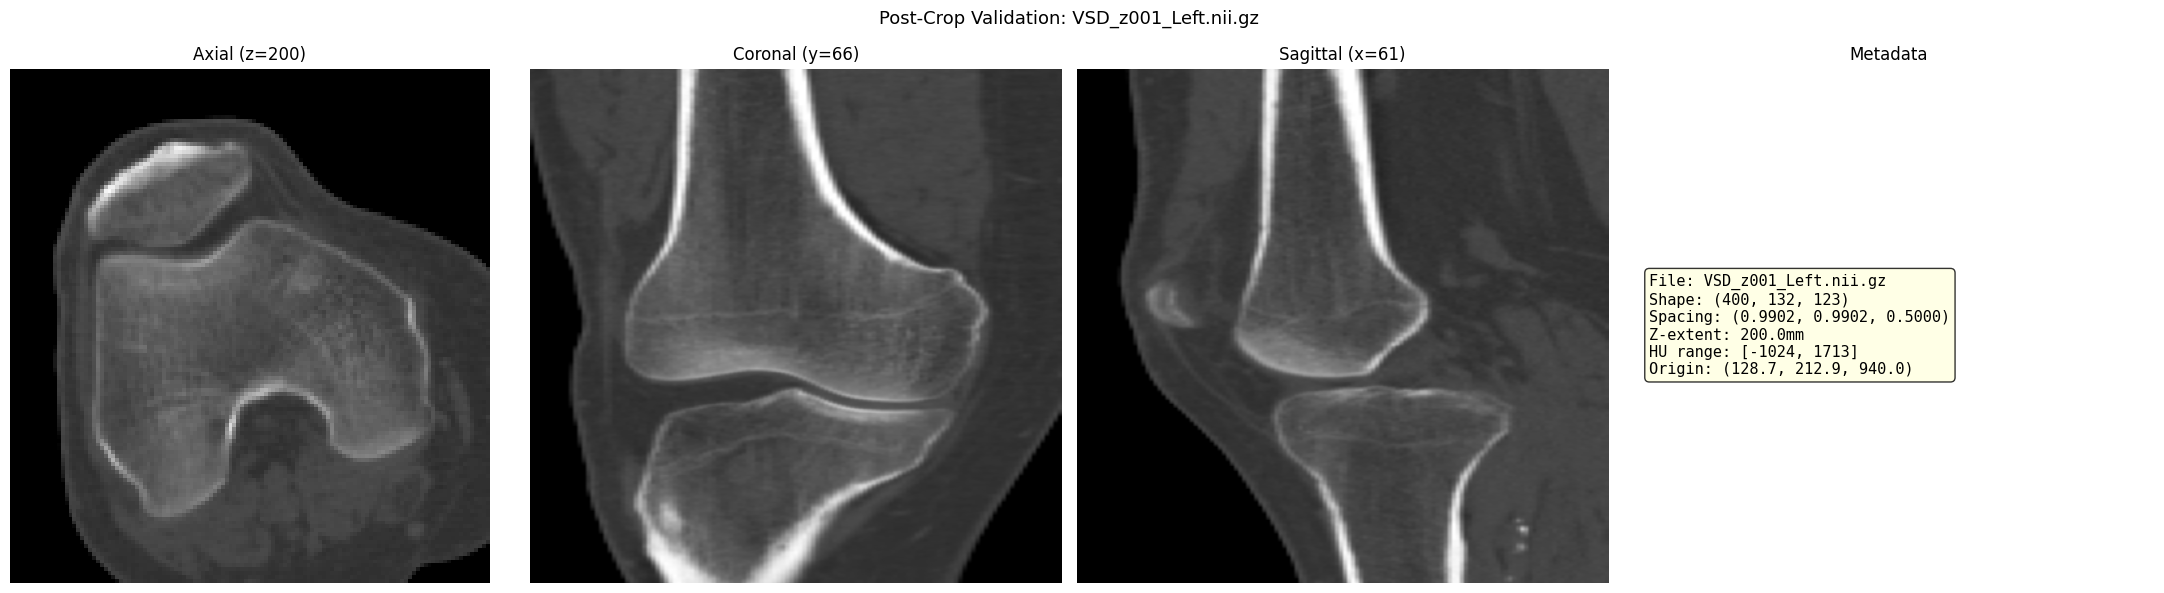

  Loading VSD_z001_Right.nii.gz...


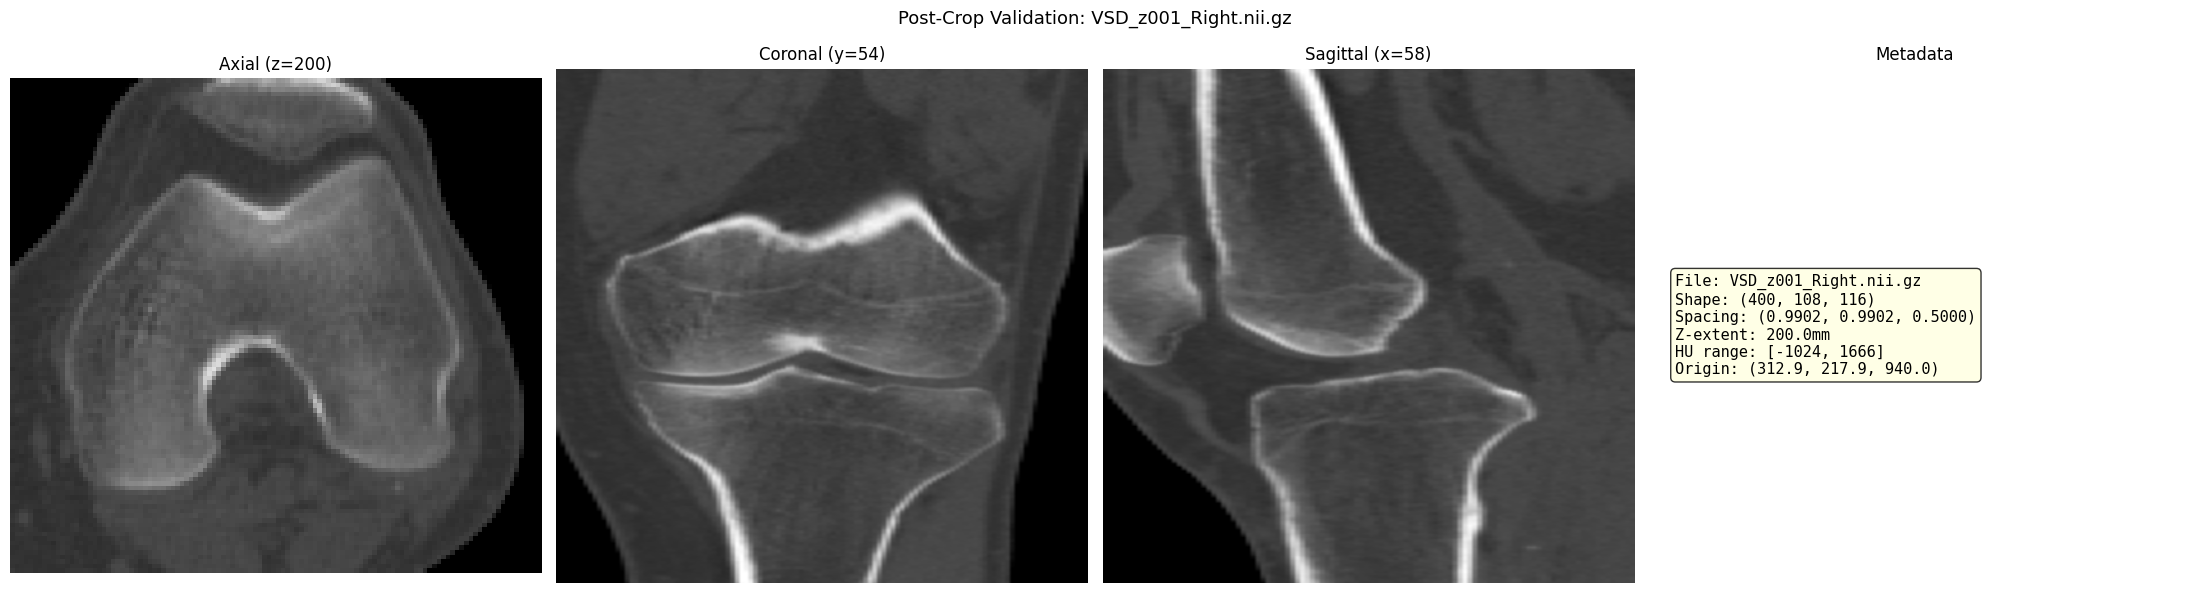

  Loading VSD_z066_Left.nii.gz...


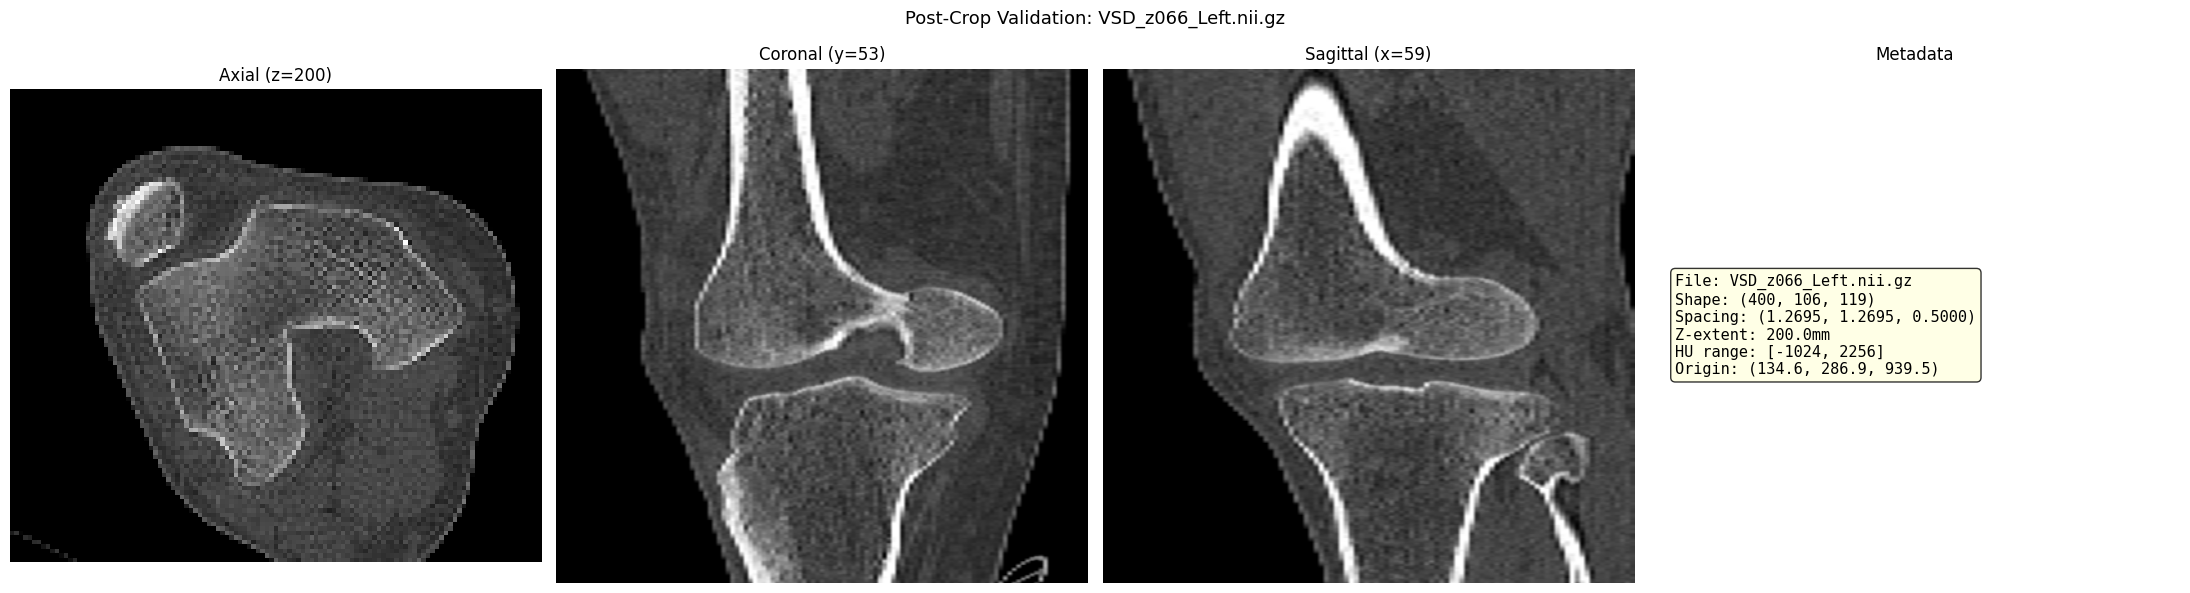

Validation complete. Check that each volume shows a single knee joint.


In [9]:
# Collect saved files for validation
left_files = sorted(OUTPUT_DIR_LEFT.glob("VSD_z*.nii.gz"))
right_files = sorted(OUTPUT_DIR_RIGHT.glob("VSD_z*.nii.gz"))

print(f"Saved knee volumes:")
print(f"  Left : {len(left_files)} files")
print(f"  Right: {len(right_files)} files")

# Pick up to 3 volumes for visual validation
validation_files = []
if left_files:
    validation_files.append(("Left", left_files[0]))
if right_files:
    validation_files.append(("Right", right_files[0]))
if len(left_files) > 1:
    validation_files.append(("Left", left_files[-1]))

print(f"\nValidating {len(validation_files)} volumes:\n")

for side, fpath in validation_files:
    fname = fpath.name
    print(f"  Loading {fname}...")

    img = sitk.ReadImage(str(fpath))
    arr = sitk.GetArrayFromImage(img).astype(np.float32)
    spacing = img.GetSpacing()

    mid_z = arr.shape[0] // 2
    mid_y = arr.shape[1] // 2
    mid_x = arr.shape[2] // 2

    fig, axes = plt.subplots(1, 4, figsize=(22, 6))

    # Axial (mid-z)
    axes[0].imshow(arr[mid_z], cmap="gray", vmin=-500, vmax=1500)
    axes[0].set_title(f"Axial (z={mid_z})")
    axes[0].axis("off")

    # Coronal (mid-y)
    axes[1].imshow(arr[:, mid_y, :], cmap="gray", vmin=-500, vmax=1500, aspect="auto")
    axes[1].set_title(f"Coronal (y={mid_y})")
    axes[1].axis("off")

    # Sagittal (mid-x)
    axes[2].imshow(arr[:, :, mid_x], cmap="gray", vmin=-500, vmax=1500, aspect="auto")
    axes[2].set_title(f"Sagittal (x={mid_x})")
    axes[2].axis("off")

    # Info panel
    axes[3].axis("off")
    info = (f"File: {fname}\n"
            f"Shape: {arr.shape}\n"
            f"Spacing: ({spacing[0]:.4f}, {spacing[1]:.4f}, {spacing[2]:.4f})\n"
            f"Z-extent: {arr.shape[0]*spacing[2]:.1f}mm\n"
            f"HU range: [{arr.min():.0f}, {arr.max():.0f}]\n"
            f"Origin: ({img.GetOrigin()[0]:.1f}, {img.GetOrigin()[1]:.1f}, "
            f"{img.GetOrigin()[2]:.1f})")
    axes[3].text(0.05, 0.5, info, transform=axes[3].transAxes, fontsize=11,
                 verticalalignment="center", fontfamily="monospace",
                 bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
    axes[3].set_title("Metadata")

    plt.suptitle(f"Post-Crop Validation: {fname}", fontsize=13)
    plt.tight_layout()
    plt.show()

    del arr, img
    gc.collect()

print("Validation complete. Check that each volume shows a single knee joint.")

## 8 — Findings & Next Steps

### Results Summary

After running all 20 z-prefix subjects through the two-stage pipeline:

| Metric | Value |
|--------|-------|
| Subjects discovered | _(fill after running Cell 2)_ |
| Knee identified (no fallback) | _(fill after running Cell 5)_ |
| Bilateral separation passed | _(fill after running Cell 5)_ |
| Overall pass rate | _(fill after running Cell 5)_ |
| Knee volumes saved | _(fill after running Cell 6)_ |

### Key Observations

- **Fixed z-crop effectiveness**: Discarding the top 45% eliminates shoulder/arm
  bone peaks that previously confused the pelvis-anchored algorithm.
- **15–35% knee range**: On the cropped lower-body sub-volume, this window
  reliably captures the knee joint peak.
- **Fallback subjects**: Any subject where the knee peak fell outside 15–35%
  should be inspected manually — check the diagnostic figure.

### Failed Subjects

_(List any subjects that failed and the reason — e.g. no peaks in range,
leg separation returned <2 components. Review the saved diagnostic figures
in `reports/figures/z_vsd_crop/`.)_

### Next Steps

1. **Review diagnostic figures** for all 20 subjects to confirm correct anatomy
2. **Merge z-prefix volumes** with the regular VSD knee volumes in `data/raw/healthy/`
3. **Proceed to CT preprocessing** (resampling, HU windowing, orientation) on the
   combined healthy dataset
4. **Update the dataset registry** to include z-prefix subjects in the training split